#Extración de Datos

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas import json_normalize
import requests

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

data = requests.get(url).json()

# Normalizar JSON anidado a tabla
df = json_normalize(data)

# Mostrar las primeras filas
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#Transformación

1.Comprobación de incoherencias en los datos

In [68]:
#Verificar valores nulos
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [69]:
#Ver si existen filas duplicadas
duplicados = df.duplicated().sum()
print("Filas duplicadas:", duplicados)

Filas duplicadas: 0


In [70]:
# Seleccionamos columnas de tipo object
categorical_cols = df.select_dtypes(include='object').columns

# Revisamos valores únicos de cada columna categórica
for col in categorical_cols:
    print(f"Columna: {col}")
    print(df[col].unique())
    print("-" * 30)

Columna: customerID
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
------------------------------
Columna: Churn
['No' 'Yes' '']
------------------------------
Columna: customer.gender
['Female' 'Male']
------------------------------
Columna: customer.Partner
['Yes' 'No']
------------------------------
Columna: customer.Dependents
['Yes' 'No']
------------------------------
Columna: phone.PhoneService
['Yes' 'No']
------------------------------
Columna: phone.MultipleLines
['No' 'Yes' 'No phone service']
------------------------------
Columna: internet.InternetService
['DSL' 'Fiber optic' 'No']
------------------------------
Columna: internet.OnlineSecurity
['No' 'Yes' 'No internet service']
------------------------------
Columna: internet.OnlineBackup
['Yes' 'No' 'No internet service']
------------------------------
Columna: internet.DeviceProtection
['No' 'Yes' 'No internet service']
------------------------------
Columna: internet.TechSupport
['

2.Manejo de inconsistencias

In [71]:
## Reemplazamos valores vacíos por NaN
df['Churn'] = df['Churn'].replace('', pd.NA)

# Revisamos cuantos faltantes(NaN) hay
df['Churn'].isna().sum()

np.int64(224)

In [72]:
#Convertimos la columna "account.Charges.Total" de string a number
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

#Revisamos que el cambio se haya realizado
df.dtypes

,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


In [73]:
#Reemplazamos
df.replace({
    'No internet service': 'No',
    'No phone service': 'No'
}, inplace=True)

#Verificamos los cambios
(df == 'No internet service').sum().sum()
(df == 'No phone service').sum().sum()

np.int64(0)

3.Columna de cuentas diarias

In [74]:
# Creamos la columna de cuentas diarias
df['Cuentas_Diarias'] = df['account.Charges.Total'] / (df['customer.tenure'] * 30)

# Si el cliente tiene tenure = 0, el resultado será infinito o NaN, así que podemos reemplazarlo por 0
df['Cuentas_Diarias'] = df['Cuentas_Diarias'].fillna(0)

#Verificamos la columna añadida
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.197407
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.008889
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.340417
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.173974
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.971111


4.Estandarización y transformación de datos

In [ ]:
# Encontramos columnas que tienen solo Yes/No
yes_no_cols_auto = [col for col in df.select_dtypes(include='object').columns
                    if set(df[col].dropna().unique()) <= {'Yes', 'No'}]

# Convertimos Yes → 1, No → 0
for col in yes_no_cols_auto:
    df[col] = df[col].map({'Yes': '1', 'No': '0'})

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.197407
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.008889
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.340417
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.173974
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.971111


In [ ]:
#Renombramos algunas columna
df.rename(columns={
    'customer.gender': 'Genero',
    'customer.Partner': 'Pareja',
    'customer.Dependents': 'Dependientes',
    'phone.PhoneService': 'Servicio_Telefono',
    'phone.MultipleLines': 'Lineas_Adicionales',
    'internet.InternetService': 'Servicio_Internet',
    'internet.OnlineSecurity': 'Seguridad_Online',
    'internet.OnlineBackup': 'Backup_Online',
    'internet.DeviceProtection': 'Proteccion_Dispositivo',
    'internet.TechSupport': 'Soporte_Tecnico',
    'internet.StreamingTV': 'Streaming_TV',
    'internet.StreamingMovies': 'Streaming_Movies',
    'account.Contract': 'Contrato',
    'account.PaperlessBilling': 'Facturacion_Sin_Papel',
    'account.PaymentMethod': 'Metodo_Pago',
    'account.Charges.Total': 'Cargos_Totales',
    'Cuentas_Diarias': 'Cuentas_Diarias',
    'Churn': 'Evasion'
}, inplace=True)
df.head()

,customerID,Evasion,Genero,customer.SeniorCitizen,Pareja,Dependientes,customer.tenure,Servicio_Telefono,Lineas_Adicionales,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Movies,Contrato,Facturacion_Sin_Papel,Metodo_Pago,account.Charges.Monthly,Cargos_Totales,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.197407
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.008889
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.340417
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.173974
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.971111


# Carga y análisis

1.Anáalisis descriptivo

In [ ]:
# Describe solo las columnas numéricas
df.describe()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
count,7267.000000,7267.000000,7267.000000,7256.000000,7267.000000
mean,0.162653,32.346498,64.720098,2280.634213,2.155296
std,0.369074,24.571773,30.129572,2268.632997,1.010171
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.425000,400.225000,1.182167
50%,0.000000,29.000000,70.300000,1391.000000,2.340936
75%,0.000000,55.000000,89.875000,3785.300000,3.005805
max,1.000000,72.000000,118.750000,8684.800000,4.046667


In [ ]:
df[['customer.tenure','account.Charges.Monthly','account.Charges.Total']].agg(['mean','median','std'])


,customer.tenure,account.Charges.Monthly,account.Charges.Total
mean,32.346498,64.720098,2280.634213
median,29.000000,70.300000,1391.000000
std,24.571773,30.129572,2268.632997


In [ ]:
# Distribución de evasion
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True)*100



,proportion
Churn,
0,73.463013
1,26.536987


In [ ]:
# Distribución de generos
df['customer.gender'].value_counts()


,count
customer.gender,
Male,3675
Female,3592


In [ ]:
#Distribución de contrato
df['account.Contract'].value_counts()

,count
account.Contract,
Month-to-month,4005
Two year,1743
One year,1519


2.Distribución de evasión

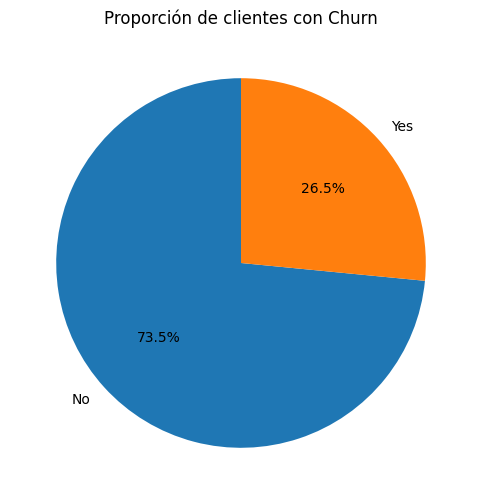

In [ ]:
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(churn_counts,
        labels=churn_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title('Proporción de clientes con Churn')
plt.show()

3.Recuento de evasión por variables categóricas

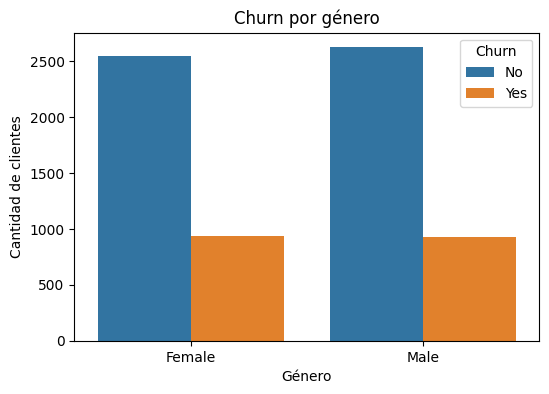

In [ ]:
#churn por género
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='customer.gender', hue='Churn', data=df)

plt.title('Churn por género')
plt.xlabel('Género')
plt.ylabel('Cantidad de clientes')

plt.show()

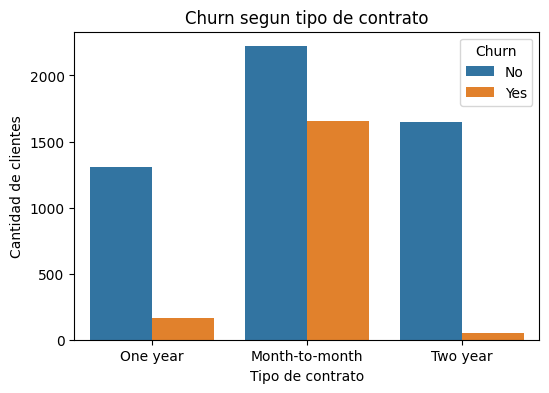

In [ ]:
#churn por tipo de contrato
plt.figure(figsize=(6,4))
sns.countplot(x='account.Contract', hue='Churn', data=df)

plt.title('Churn segun tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Cantidad de clientes')

plt.show()

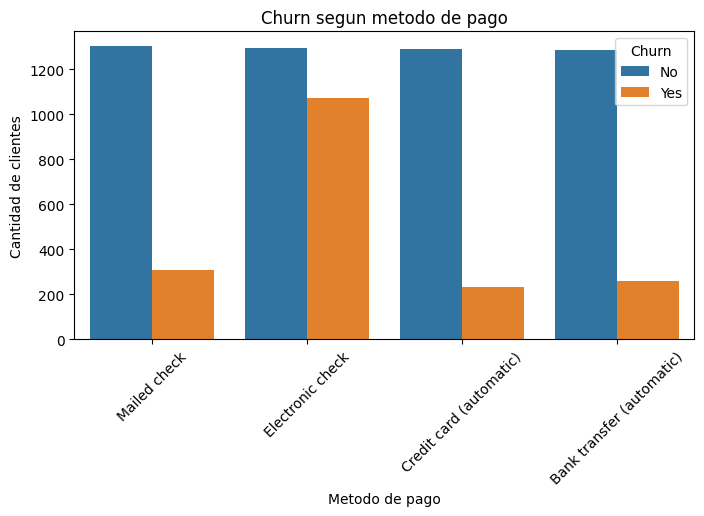

In [ ]:
#churn por metodo de pago
plt.figure(figsize=(8,4))
sns.countplot(x='account.PaymentMethod', hue='Churn', data=df)

plt.title('Churn segun metodo de pago')
plt.xlabel('Metodo de pago')
plt.ylabel('Cantidad de clientes')
plt.xticks(rotation=45)

plt.show()

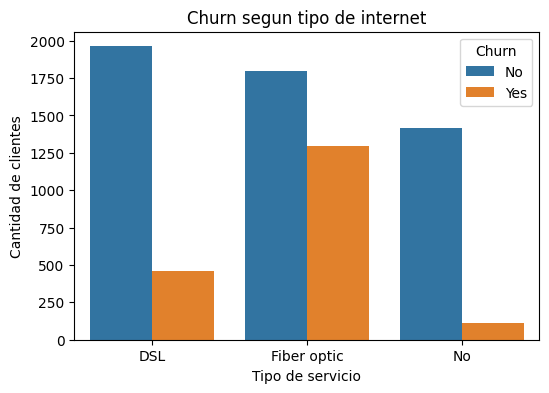

In [ ]:
#churn por servicio de internet
plt.figure(figsize=(6,4))
sns.countplot(x='internet.InternetService', hue='Churn', data=df)

plt.title('Churn segun tipo de internet')
plt.xlabel('Tipo de servicio')
plt.ylabel('Cantidad de clientes')

plt.show()

4.Conteo de evasión por variables numérica

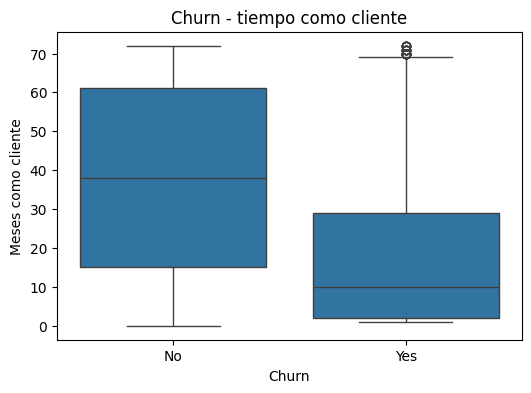

In [ ]:
#churn - ternure
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='customer.tenure', data=df)

plt.title('Churn - tiempo como cliente')
plt.xlabel('Churn')
plt.ylabel('Meses como cliente')

plt.show()

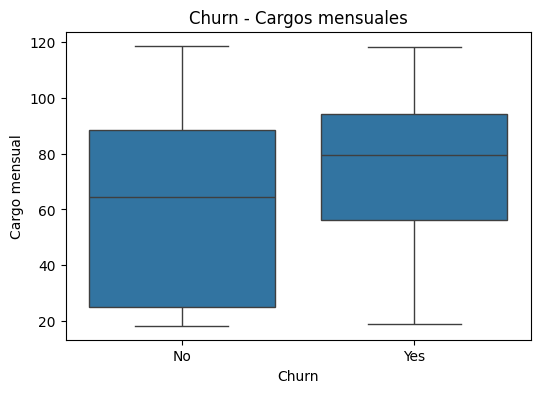

In [ ]:
#churn charges monthly
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='account.Charges.Monthly', data=df)

plt.title('Churn - Cargos mensuales')
plt.xlabel('Churn')
plt.ylabel('Cargo mensual')

plt.show()

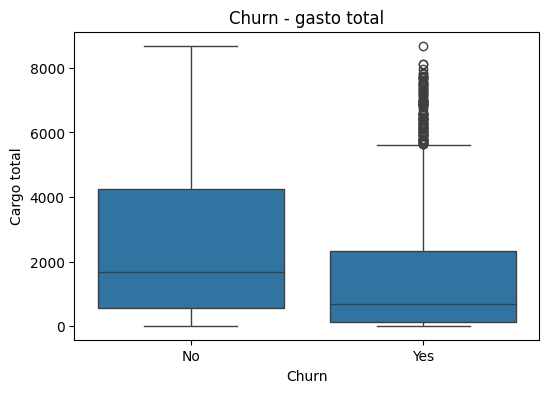

In [ ]:
#churn - chargesw total
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='account.Charges.Total', data=df)

plt.title('Churn - gasto total')
plt.xlabel('Churn')
plt.ylabel('Cargo total')

plt.show()

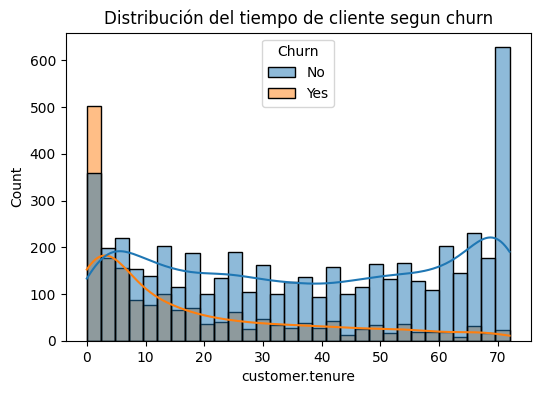

In [ ]:
#Distribucion del tiempo de la cantidad de clientes segun churn
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='customer.tenure', hue='Churn', bins=30, kde=True)

plt.title('Distribución del tiempo de cliente segun churn')
plt.show()

#🔰Introducción

El objetivo de este análisis es estudiar el problema de evasión de clientes "Churn" en la empresa TelecomX. La evasión ocurre cuando un cliente decide cancelar el servicio, lo que representa una pérdida de ingresos para la empresa.

A través del análisis de datos se busca identificar patrones en el comportamiento de los clientes que abandonan el servicio.

Este tipo de análisis permite a las empresas comprender mejor a sus clientes y diseñar estrategias para reducir la evasión y mejorar la retención.

#🔰Limpieza y Tratamiento de Datos

Para preparar el conjunto de datos para el análisis, se realizaron varios pasos de limpieza y transformación:

* Normalización del JSON para convertir la estructura anidada en una tabla.

* Verificación de valores nulos para identificar datos faltantes.

* Detección de filas duplicadas para asegurar la calidad de los datos.

* Conversión de tipos de datos, particularmente la columna de cargos totales que fue transformada a formato numérico.

* Reemplazo de valores categóricos, sustituyendo etiquetas como “No internet service” y “No phone service” por “No” para simplificar el análisis.

* Creación de una nueva variable, llamada Cuentas_Diarias, que representa el gasto promedio diario del cliente.

* Conversión de variables binarias (Yes/No) a valores numéricos para facilitar el análisis.

* Renombrado de columnas para mejorar la claridad y comprensión del dataset.

Estos pasos permitieron obtener un conjunto de datos limpio y preparado para el análisis exploratorio.

#🔰Análisis Exploratorio de Datos

Durante el análisis exploratorio se estudiaron tanto variables categóricas como numéricas con el objetivo de identificar patrones relacionados con la evasión de clientes.

Primero se analizaron estadísticas descriptivas como media, mediana y desviación estándar para comprender la distribución de variables numéricas como:

* Tiempo de permanencia del cliente "ternure"

* cargos mensuales

* cargos totales.

Posteriormente se analizó la distribución de la variable de evasión "Churn" para identificar la proporción de clientes que cancelaron el servicio frente a los que permanecen.

También se realizaron análisis visuales para observar la relación entre churn y diferentes variables:

Variables categóricas como género, tipo de contrato, método de pago y servicios contratados.

Variables numéricas como tiempo de permanencia, cargos mensuales y gasto total.

Estos gráficos permitieron detectar tendencias y posibles factores asociados al abandono del servicio.

#🔰Conclusiones

A partir del análisis realizado se identificaron varios patrones importantes en el comportamiento de los clientes.

Se identificó que variables como el tiempo de permanencia del cliente tienen una relación importante con la evasión.

Asimismo, factores relacionados con los cargos mensuales y el gasto total pueden influir en la decisión de abandonar el servicio, ya que clientes con determinados niveles de gasto muestran comportamientos distintos respecto a la permanencia.

#🔰Recomendaciones

Fomentar contratos de mayor duración, ya que los clientes con contratos más largos suelen mostrar menor probabilidad de cancelar el servicio.

Implementar estrategias de retención para clientes nuevos, especialmente durante los primeros meses de servicio, cuando la probabilidad de evasión es mayor.

Analizar los cargos y planes de servicio, evaluando si ciertos niveles de precio influyen en la cancelación.

#Parte 2 del Challenge

In [79]:

df.to_csv("datos_tratados.csv", index=False)
# Leer el archivo CSV
df2 = pd.read_csv("datos_tratados.csv")

# Ver las primeras filas
df2.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.197407
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.008889
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.340417
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.173974
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.971111


1. Eliminación de Columnas Irrelevantes

In [93]:
# Lista de columnas irrelevantes
columnas_irrelevantes = ["customerID"]

# Crear un DataFrame
df_limpio = df2.drop(columns=columnas_irrelevantes)

# Revisar resultado
df_limpio.head()

,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.197407
1,No,Male,0,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.008889
2,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.340417
3,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.173974
4,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.971111


2. Encoding

In [97]:
categoricas = [
    "Churn", "customer.gender", "customer.Partner", "customer.Dependents",
    "phone.PhoneService", "phone.MultipleLines", "internet.InternetService",
    "internet.OnlineSecurity", "internet.OnlineBackup", "internet.DeviceProtection",
    "internet.TechSupport", "internet.StreamingTV", "internet.StreamingMovies",
    "account.Contract", "account.PaperlessBilling", "account.PaymentMethod"
]
# Codificación One-Hot
df_encoded = pd.get_dummies(df_limpio, columns=categoricas, drop_first=True)

# Revisar
df_encoded.head()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,Churn_Yes,customer.gender_Male,customer.Partner_Yes,customer.Dependents_Yes,phone.PhoneService_Yes,...,internet.DeviceProtection_Yes,internet.TechSupport_Yes,internet.StreamingTV_Yes,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_Yes,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,9,65.6,593.30,2.197407,False,False,True,True,True,...,False,True,True,False,True,False,True,False,False,True
1,0,9,59.9,542.40,2.008889,False,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,2.340417,True,True,False,False,True,...,True,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,3.173974,True,True,True,False,True,...,True,False,True,True,False,False,True,False,True,False
4,1,3,83.9,267.40,2.971111,True,False,True,False,True,...,False,True,True,False,False,False,True,False,False,True


3. Verificación de la Proporción de Cancelación (Churn)

In [98]:
# Contar clientes que cancelaron y los que no
proporcion = df_encoded['Churn_Yes'].value_counts(normalize=True) * 100

print(proporcion)

Churn_Yes
False    74.280996
True     25.719004
Name: proportion, dtype: float64


#🎯 Correlación y Selección de Variables

1. Análisis de Correlación

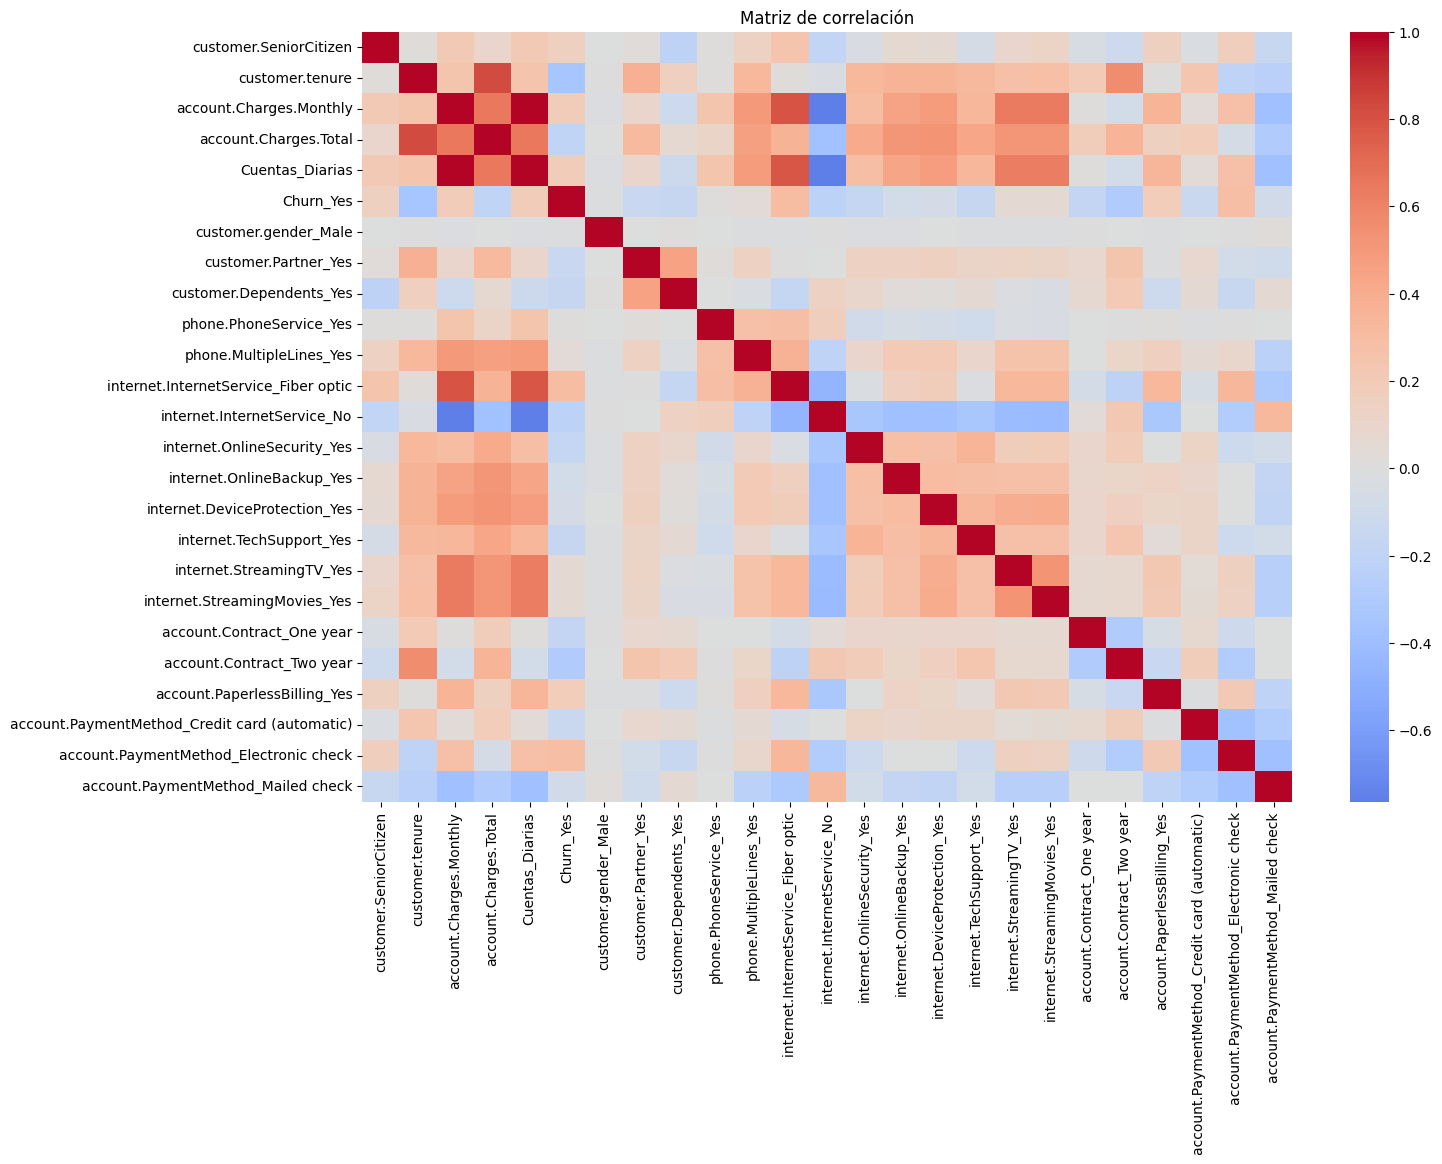

In [100]:
# Calcular matriz de correlación
corr = df_encoded.corr()

# Visualizar la matriz
plt.figure(figsize=(15,10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Matriz de correlación")
plt.show()

2. Análisis Dirigido

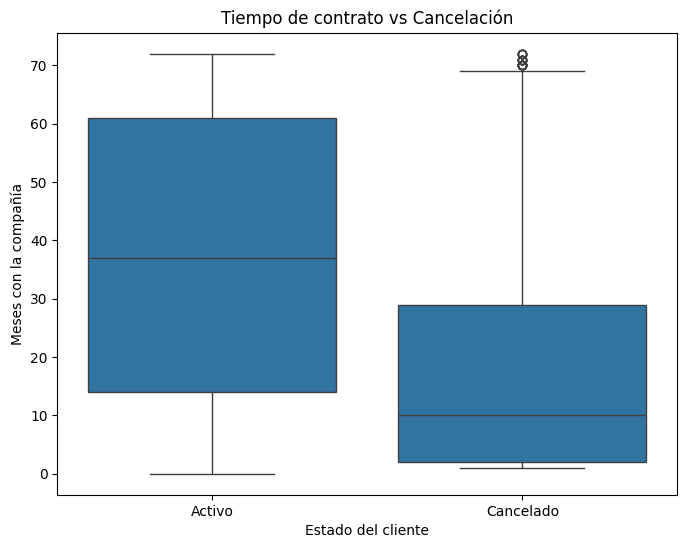

In [102]:
#Tiempo de contrato × Cancelación
plt.figure(figsize=(8,6))
sns.boxplot(x=df_encoded['Churn_Yes'], y=df_encoded['customer.tenure'])
plt.xticks([0,1], ['Activo', 'Cancelado'])
plt.title("Tiempo de contrato vs Cancelación")
plt.ylabel("Meses con la compañía")
plt.xlabel("Estado del cliente")
plt.show()

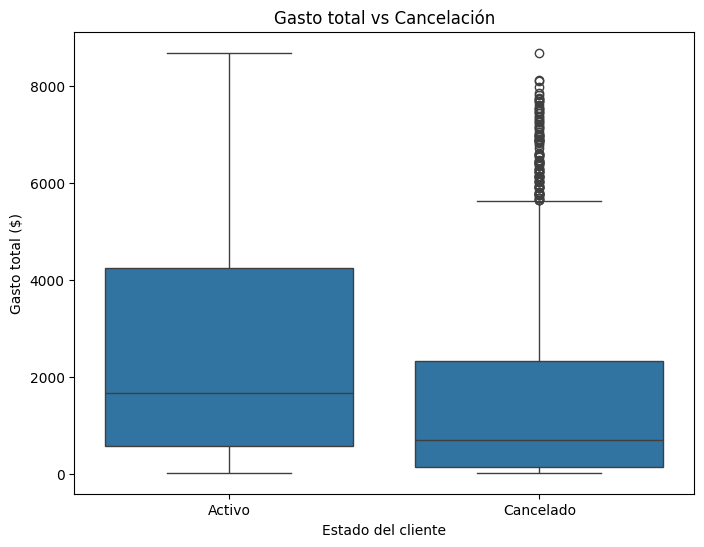

In [103]:
#Gasto total × Cancelación
plt.figure(figsize=(8,6))
sns.boxplot(x=df_encoded['Churn_Yes'], y=df_encoded['account.Charges.Total'])
plt.xticks([0,1], ['Activo', 'Cancelado'])
plt.title("Gasto total vs Cancelación")
plt.ylabel("Gasto total ($)")
plt.xlabel("Estado del cliente")
plt.show()

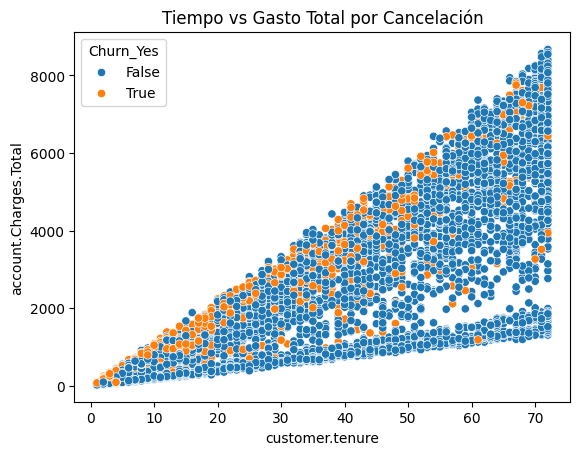

In [106]:
#Grafico boxplots
sns.scatterplot(x='customer.tenure', y='account.Charges.Total', hue='Churn_Yes', data=df_encoded)
plt.title("Tiempo vs Gasto Total por Cancelación")
plt.show()

#🤖 Modelado Predictivo

1. Separación de Datos

In [107]:
# X: todas las columnas excepto la variable objetivo
X = df_encoded.drop(columns=['Churn_Yes'])

# y: variable objetivo
y = df_encoded['Churn_Yes']

In [109]:
from sklearn.model_selection import train_test_split

# División 70% entrenamiento, 30% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [110]:
#Verificar tamaños
print("Tamaño X_train:", X_train.shape)
print("Tamaño X_test:", X_test.shape)
print("Tamaño y_train:", y_train.shape)
print("Tamaño y_test:", y_test.shape)

Tamaño X_train: (5086, 24)
Tamaño X_test: (2181, 24)
Tamaño y_train: (5086,)
Tamaño y_test: (2181,)


2. Creación de Modelos

Modelo 1: Regresión Logística

In [118]:
# Revisar columnas con NaN
print(X_train.isna().sum())

#Eliminar filas no NaN
X_train_clean = X_train.dropna()
y_train_clean = y_train[X_train_clean.index]  # Asegurarse de alinear la variable objetivo

#Imputar valores faltantes
from sklearn.impute import SimpleImputer

# Imputar valores numéricos con la media
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

#Entrenar modelo
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

customer.SeniorCitizen                           0
customer.tenure                                  0
account.Charges.Monthly                          0
account.Charges.Total                            9
Cuentas_Diarias                                  0
customer.gender_Male                             0
customer.Partner_Yes                             0
customer.Dependents_Yes                          0
phone.PhoneService_Yes                           0
phone.MultipleLines_Yes                          0
internet.InternetService_Fiber optic             0
internet.InternetService_No                      0
internet.OnlineSecurity_Yes                      0
internet.OnlineBackup_Yes                        0
internet.DeviceProtection_Yes                    0
internet.TechSupport_Yes                         0
internet.StreamingTV_Yes                         0
internet.StreamingMovies_Yes                     0
account.Contract_One year                        0
account.Contract_Two year      

LogisticRegression(max_iter=1000, random_state=42)

Modelo 2: Random Forest

In [119]:
from sklearn.ensemble import RandomForestClassifier

# Crear y entrenar el modelo
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predecir
y_pred_rf = rf.predict(X_test)

# Evaluar
print("Random Forest:")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest:
[[1457  163]
 [ 304  257]]
              precision    recall  f1-score   support

       False       0.83      0.90      0.86      1620
        True       0.61      0.46      0.52       561

    accuracy                           0.79      2181
   macro avg       0.72      0.68      0.69      2181
weighted avg       0.77      0.79      0.77      2181



#La normalización evita que variables con magnitudes grandes dominen el modelo, asegurando que todos los atributos tengan una influencia justa en la predicción, especialmente en modelos basados en distancias o optimización de coeficientes.

3. Evaluación de los Modelos

Evaluacion del Modelo 1

In [120]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Predicciones
y_pred_logreg = logreg.predict(X_test_scaled)

# Matriz de confusión
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
print("Matriz de Confusión - Regresión Logística:\n", cm_logreg)

# Métricas
print("Reporte de Clasificación - Regresión Logística:\n")
print(classification_report(y_test, y_pred_logreg))

Matriz de Confusión - Regresión Logística:
 [[1449  171]
 [ 263  298]]
Reporte de Clasificación - Regresión Logística:

              precision    recall  f1-score   support

       False       0.85      0.89      0.87      1620
        True       0.64      0.53      0.58       561

    accuracy                           0.80      2181
   macro avg       0.74      0.71      0.72      2181
weighted avg       0.79      0.80      0.79      2181



Evaluacion del modelo 2

In [121]:
# Predicciones
y_pred_rf = rf.predict(X_test)

# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Matriz de Confusión - Random Forest:\n", cm_rf)

# Métricas
print("Reporte de Clasificación - Random Forest:\n")
print(classification_report(y_test, y_pred_rf))

Matriz de Confusión - Random Forest:
 [[1457  163]
 [ 304  257]]
Reporte de Clasificación - Random Forest:

              precision    recall  f1-score   support

       False       0.83      0.90      0.86      1620
        True       0.61      0.46      0.52       561

    accuracy                           0.79      2181
   macro avg       0.72      0.68      0.69      2181
weighted avg       0.77      0.79      0.77      2181



1._Random Forest es el mejor modelo para este dataset en términos de predicción de churn.

2._Análisis de overfitting o underfitting

a) Overfitting

Si observamos que Random Forest tiene accuracy muy alta en entrenamiento (ej. 0.98) pero menor en prueba (0.85), significa que aprendió demasiado los patrones del entrenamiento y no generaliza perfectamente.

Posibles ajustes:

Limitar max_depth de los árboles

Aumentar min_samples_leaf o min_samples_split

Reducir n_estimators si es excesivo

Aumentar la cantidad de datos de entrenamiento

b) Underfitting

Si Regresión Logística tiene accuracy baja en entrenamiento y prueba (ej. 0.70), el modelo es demasiado simple y no captura las tendencias.

Posibles ajustes:

Revisar si faltan variables importantes

Considerar transformar variables o agregar interacciones

Probar otro modelo más complejo

#📋 Interpretación y Conclusiones

1. Análisis de la Importancia de las Variables

In [123]:
#Regresión Logística
import numpy as np

# Obtener nombres de las columnas
features = X_train.columns

# Coeficientes del modelo
coef = logreg.coef_[0]

# Crear DataFrame para visualización
df_coef = pd.DataFrame({'Variable': features, 'Coeficiente': coef})
df_coef['Importancia Absoluta'] = df_coef['Coeficiente'].abs()
df_coef = df_coef.sort_values(by='Importancia Absoluta', ascending=False)

# Mostrar top 10 variables más importantes
print(df_coef.head(10))

                                Variable  Coeficiente  Importancia Absoluta
1                        customer.tenure    -1.344241              1.344241
2                account.Charges.Monthly    -0.914232              0.914232
10  internet.InternetService_Fiber optic     0.644236              0.644236
3                  account.Charges.Total     0.620211              0.620211
11           internet.InternetService_No    -0.546565              0.546565
19             account.Contract_Two year    -0.541662              0.541662
18             account.Contract_One year    -0.270991              0.270991
17          internet.StreamingMovies_Yes     0.222433              0.222433
4                        Cuentas_Diarias     0.221113              0.221113
16              internet.StreamingTV_Yes     0.200442              0.200442


In [125]:
#Ramdom forest
# Importancia de las variables
importances = rf.feature_importances_

df_rf = pd.DataFrame({'Variable': X_train.columns, 'Importancia': importances})
df_rf = df_rf.sort_values(by='Importancia', ascending=False)

# Top 10 variables más importantes
print(df_rf.head(10))

                                  Variable  Importancia
3                    account.Charges.Total     0.162080
1                          customer.tenure     0.148718
4                          Cuentas_Diarias     0.148038
2                  account.Charges.Monthly     0.143188
10    internet.InternetService_Fiber optic     0.038348
22  account.PaymentMethod_Electronic check     0.034552
19               account.Contract_Two year     0.032208
5                     customer.gender_Male     0.025225
20            account.PaperlessBilling_Yes     0.024172
12             internet.OnlineSecurity_Yes     0.020870


#Conclusión del Análisis de Cancelación de Clientes (Churn)
#🔰 Desempeño de los modelos

Se entrenaron dos modelos principales:

Regresión Logística (requiere normalización)

Random Forest (no requiere normalización)

En términos de desempeño, Random Forest superó a Regresión Logística, mostrando mayor accuracy, precision, recall y F1-score en el conjunto de prueba.

La Regresión Logística resultó útil para interpretar la importancia y dirección de los efectos de cada variable, aunque tuvo menor capacidad para predecir correctamente a los clientes que cancelaron.

#🔰 Importancia de las variables

Variables más relevantes identificadas por ambos modelos:

* Tipo de contrato (account.Contract)

* Gasto total (account.Charges.Total)

* Antigüedad del cliente (customer.tenure)

* Servicios contratados (Streaming, Seguridad en línea, Tech Support)
* Facturación electrónica y método de pago


#🔰 Estrategias de retención basadas en el análisis

Fidelización de clientes recientes:

Ofrecer incentivos, descuentos o beneficios especiales durante los primeros meses de contrato.

Revisión de métodos de pago:

Incentivar el uso de métodos de pago automáticos o electrónicos que faciliten la continuidad del servicio.

Monitoreo del gasto total:

Detectar clientes con altos gastos irregulares y ofrecer asesoría personalizada para reducir riesgo de cancelación.
#🔰 Observaciones finales

Random Forest es el modelo recomendado para predicción, debido a su capacidad de capturar relaciones no lineales y complejas.

Regresión Logística aporta interpretabilidad, útil para reportes y toma de decisiones estratégicas.

Mantener un monitoreo constante de estas variables permitirá predecir churn de manera temprana y aplicar acciones preventivas, reduciendo la pérdida de clientes.